# 🤖 OnePilot — ML Relation Detector v6
**Améliorations v5 :**
- ✅ [v5] Bug 1 corrigé : plus de data leakage dans les positifs
- ✅ [v5] Bug 2 corrigé : hard negatives 30% (cas difficiles)
- ✅ [v5] Bug 3a corrigé : seuil auto via courbe Precision/Recall
- ✅ [v5] Bug 3b corrigé : `confidence_score` → `confidence` dans le résumé final
- ✅ [v5] `sim()` remplacé par bigrams Jaccard (50× plus rapide)
- ✅ Hard negatives utilisent aussi bigrams (plus de SequenceMatcher)
- ✅ [v5] **Profiling features** : `value_overlap`, `cardinality_ratio`, `null_rate_compat`
- ✅ [v5] **16 features**
- 🆕 **[v6] Profiling features ACTIVÉES** (value_overlap, cardinality_ratio, null_rate_compat vraiment connectées)
- 🆕 **[v6] Bug insertion corrigé** : existing_set vidé après DELETE → les 500 prédictions s'insèrent maintenant
- 🆕 **[v6] Nettoyage sources fantômes** : cellule dédiée pour supprimer les sources orphelines en DB
- 🆕 **[v6] Hyperparams améliorés** : XGBoost (n=500, reg_lambda, scale_pos_weight auto) + sample_weight utilisé au fit au lieu de 13 (si profiling disponible)

## 1. 📦 Imports & Config

In [1]:
FEATURE_COLS = [
    'name_sim', 'norm_sim', 'entity_in_field', 'type_compat',
    'fk_pattern_a', 'fk_pattern_b', 'pk_fk_pair', 'common_parts',
    'name_contains_entity_a', 'name_contains_entity_b',
    'len_diff', 'prefix_match', 'suffix_match',
    # ── 3 profiling features (actives si entity_profiles disponibles) ──
    'value_overlap', 'cardinality_ratio', 'null_rate_compat',
]

print('✅ Config OK — tous les imports chargés')
print(f'   {len(FEATURE_COLS)} features : {FEATURE_COLS}')

✅ Config OK — tous les imports chargés
   16 features : ['name_sim', 'norm_sim', 'entity_in_field', 'type_compat', 'fk_pattern_a', 'fk_pattern_b', 'pk_fk_pair', 'common_parts', 'name_contains_entity_a', 'name_contains_entity_b', 'len_diff', 'prefix_match', 'suffix_match', 'value_overlap', 'cardinality_ratio', 'null_rate_compat']


In [5]:
import asyncpg
import pandas as pd
import numpy as np
import re, pickle, warnings
warnings.filterwarnings('ignore')
from collections import defaultdict
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import xgboost as xgb

DB_CONFIG = {
    'host':     'onepilot_postgres',
    'port':     5432,
    'database': 'onepilot_dev',
    'user':     'onepilot',
    'password': 'onepilot_secret'
}
print('✅ Imports OK')

✅ Imports OK


## 2. 🔌 Connexion DB

In [6]:

async def get_conn():
    return await asyncpg.connect(**DB_CONFIG)

conn = await get_conn()
v = await conn.fetchval('SELECT version()')
await conn.close()
print(f'✅ PostgreSQL connecté : {v[:40]}...')

✅ PostgreSQL connecté : PostgreSQL 16.13 on x86_64-pc-linux-musl...


## 3. 📊 Sélection de la Source

In [7]:
SOURCE_IDX = 0   # 0 = source avec le plus d'entités

conn = await get_conn()
sources = await conn.fetch("""
    SELECT ds.id, ds.name, ds.connector_type,
           COUNT(DISTINCT se.id) AS entity_count,
           COUNT(DISTINCT er.id) AS relation_count
    FROM data_sources ds
    LEFT JOIN source_entities se ON se.source_id = ds.id
    LEFT JOIN entity_relations er ON er.source_id = ds.id
        AND er.detection_method != 'ml_predicted'
    GROUP BY ds.id, ds.name, ds.connector_type
    ORDER BY entity_count DESC
""")
await conn.close()

print('📋 Sources disponibles :')
for i, s in enumerate(sources):
    marker = ' ← SÉLECTIONNÉE' if i == SOURCE_IDX else ''
    print(f'  [{i}] {s["name"]} | {s["connector_type"]} | '
          f'{s["entity_count"]} entités | {s["relation_count"]} relations{marker}')

SOURCE_ID   = sources[SOURCE_IDX]['id']
SOURCE_NAME = sources[SOURCE_IDX]['name']
print(f'\n✅ Source : {SOURCE_NAME} ({SOURCE_ID})')

📋 Sources disponibles :
  [0] SXA | mssql | 1264 entités | 3327 relations ← SÉLECTIONNÉE
  [1] adata | odata | 26 entités | 10 relations
  [2] OData Demo Service | odata | 26 entités | 10 relations
  [3] Northwind OData | odata | 26 entités | 14 relations
  [4] northwind | mssql | 12 entités | 12 relations
  [5] test | file_csv | 1 entités | 0 relations
  [6] JSONPlaceholder API | rest | 0 entités | 0 relations

✅ Source : SXA (03add1dc-754a-476a-bbd5-1e53a05bf8d7)


In [8]:
# ── 🧹 Nettoyage des sources fantômes (supprimées UI mais encore en DB) ──
# ⚠️  Exécuter ce bloc UNE FOIS si tu vois des doublons dans la liste ci-dessus
# Affiche les sources sans entités ET sans relations réelles

conn = await get_conn()
orphans = await conn.fetch("""
    SELECT ds.id, ds.name, ds.connector_type,
           COUNT(DISTINCT se.id) AS entity_count,
           COUNT(DISTINCT er.id) AS relation_count
    FROM data_sources ds
    LEFT JOIN source_entities se ON se.source_id = ds.id
    LEFT JOIN entity_relations er ON er.source_id = ds.id
    GROUP BY ds.id, ds.name, ds.connector_type
    HAVING COUNT(DISTINCT se.id) = 0 AND COUNT(DISTINCT er.id) = 0
    ORDER BY ds.name
""")
await conn.close()

if not orphans:
    print('✅ Aucune source fantôme détectée')
else:
    print(f'⚠️  {len(orphans)} source(s) fantôme(s) trouvée(s) :')
    for o in orphans:
        print(f'   [{o["id"]}] {o["name"]} ({o["connector_type"]})')
    print()
    print('Pour supprimer, décommente et exécute le bloc suivant :')
    ids_to_delete = [str(o['id']) for o in orphans]
    print(f"  IDs à supprimer : {ids_to_delete}")


⚠️  1 source(s) fantôme(s) trouvée(s) :
   [47c29291-20e0-4852-a5ab-5a6be67b95de] JSONPlaceholder API (rest)

Pour supprimer, décommente et exécute le bloc suivant :
  IDs à supprimer : ['47c29291-20e0-4852-a5ab-5a6be67b95de']


In [9]:
# ── 💣 SUPPRESSION des sources fantômes — décommenter et adapter ORPHAN_IDS ──
# ⚠️  ATTENTION : supprime en cascade entités + relations + secrets

# ORPHAN_IDS = ['uuid-1', 'uuid-2']  # ← coller les IDs affichés ci-dessus
#
# conn = await get_conn()
# async with conn.transaction():
#     for oid in ORPHAN_IDS:
#         import uuid
#         uid = uuid.UUID(oid)
#         await conn.execute("DELETE FROM connection_secrets WHERE source_id=$1", uid)
#         await conn.execute("DELETE FROM entity_relations  WHERE source_id=$1", uid)
#         await conn.execute("DELETE FROM entity_fields     WHERE entity_id IN "
#                            "(SELECT id FROM source_entities WHERE source_id=$1)", uid)
#         await conn.execute("DELETE FROM source_entities   WHERE source_id=$1", uid)
#         await conn.execute("DELETE FROM entity_profiles   WHERE source_id=$1", uid)
#         r = await conn.execute("DELETE FROM data_sources WHERE id=$1", uid)
#         print(f'🗑️  Source {oid} supprimée : {r}')
# await conn.close()
# print('✅ Nettoyage terminé')

print('ℹ️  Bloc désactivé — décommenter les lignes ci-dessus pour supprimer')


ℹ️  Bloc désactivé — décommenter les lignes ci-dessus pour supprimer


## 4. 📥 Chargement des données

In [10]:
conn = await get_conn()

fields_rows = await conn.fetch("""
    SELECT se.id AS entity_id, se.name AS entity_name,
           ef.name AS field_name, ef.data_type,
           ef.is_primary_key, ef.is_foreign_key, ef.position
    FROM source_entities se
    JOIN entity_fields ef ON ef.entity_id = se.id
    WHERE se.source_id = $1
    ORDER BY se.name, ef.position
""", SOURCE_ID)

# Toutes les méthodes avec poids de confiance
relations_rows = await conn.fetch("""
    SELECT source_entity, source_field, target_entity, target_field,
           detection_method, confidence,
           CASE
               WHEN detection_method = 'explicit_fk'  THEN 1.0
               WHEN detection_method = 'view_join'    THEN 1.0
               WHEN detection_method = 'name_pascal'  THEN 0.8
               WHEN detection_method = 'name_m2m'     THEN 0.7
               WHEN detection_method = 'fuzzy_match'  THEN 0.5
               ELSE 0.6
           END as sample_weight
    FROM entity_relations
    WHERE source_id = $1
      AND detection_method != 'ml_predicted'
    ORDER BY confidence DESC
""", SOURCE_ID)

await conn.close()

df_fields    = pd.DataFrame([dict(r) for r in fields_rows])
df_relations = pd.DataFrame([dict(r) for r in relations_rows])

print(f'✅ Champs chargés   : {len(df_fields):,}')
print(f'   Entités          : {df_fields["entity_name"].nunique():,}')
print(f'✅ Relations (pos)  : {len(df_relations):,}')
print(f'   Méthodes         : {df_relations["detection_method"].value_counts().to_dict()}')
print(f'   Poids moyens     : {df_relations["sample_weight"].mean():.3f}')

✅ Champs chargés   : 12,219
   Entités          : 1,264
✅ Relations (pos)  : 3,327
   Méthodes         : {'explicit_fk': 2483, 'name_pascal': 822, 'name_m2m': 12, 'fuzzy_match': 10}
   Poids moyens     : 0.948


## 4b. 📊 Chargement des profils (entity_profiles)
*Utilisés pour les 3 features profiling. Si absent pour une table → valeurs neutres.*

In [11]:
import json as _json

conn = await get_conn()
profile_rows = await conn.fetch("""
    SELECT entity_name, profile_data
    FROM entity_profiles
    WHERE source_id = $1
      AND profile_data->>'error' IS NULL
      AND (profile_data->>'total_rows')::int > 0
""", SOURCE_ID)
await conn.close()

# Index profil : {(TABLE, CHAMP) -> {unique_count, null_rate, top_values}}
profile_index = {}
for row in profile_rows:
    table = row['entity_name'].upper()
    data  = row['profile_data']
    if isinstance(data, str):
        data = _json.loads(data)
    for col in data.get('columns', []):
        key = (table, col['name'].upper())
        top_vals = set(str(v['value']) for v in col.get('top_values', []))
        profile_index[key] = {
            'unique_count': col.get('unique_count', 0),
            'null_rate':    col.get('null_rate', 0.5),
            'top_values':   top_vals,
        }

tables_profiled = len(set(k[0] for k in profile_index))
print(f'✅ Profils chargés  : {len(profile_index):,} champs indexés')
print(f'   Tables profilées : {tables_profiled}')
if tables_profiled == 0:
    print('   ⚠️  Aucun profil disponible → value_overlap=0, ratios=0.5 (valeurs neutres)')
    print('   💡 Pour profiler : POST /sources/{id}/profile/all depuis l\'API')

✅ Profils chargés  : 5,197 champs indexés
   Tables profilées : 466


## 5. 🔧 Feature Engineering (16 features)
- 13 features de noms/types (bigrams Jaccard — 50× plus rapide)
- 3 features profiling (value_overlap, cardinality_ratio, null_rate_compat)

In [12]:
FK_PATTERNS = ['_id','_fk','id_','fk_','_code','_num','_no','_key','_ref']
TYPE_GROUPS = {
    'int':  ['int','integer','bigint','smallint','tinyint','numeric','decimal','number'],
    'str':  ['varchar','nvarchar','char','nchar','text','ntext','string'],
    'date': ['date','datetime','datetime2','timestamp'],
}

def normalize(name):
    n = name.lower()
    for p in ['fk_','pk_','id_','num_','cod_','f_','c_']:
        if n.startswith(p): n = n[len(p):]; break
    for s in ['_id','_fk','_pk','_key','_code','_num','_no','_ref']:
        if n.endswith(s): n = n[:-len(s)]; break
    return n

def type_group(dtype):
    d = dtype.lower()
    return next((g for g, ts in TYPE_GROUPS.items() if any(t in d for t in ts)), 'other')

def fk_pat(name):
    n = name.lower()
    return float(any(n.startswith(p) or n.endswith(p) for p in FK_PATTERNS))

def sim(a, b):
    """Similarité Jaccard sur les bigrams — rapide."""
    a, b = a.lower(), b.lower()
    if a == b: return 1.0
    if not a or not b: return 0.0
    sa = set(a[i:i+2] for i in range(len(a)-1))
    sb = set(b[i:i+2] for i in range(len(b)-1))
    if not sa and not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

def camel_parts(name):
    return set(p.lower() for p in re.sub(r'([A-Z])', r' \1', name).split() if len(p) > 1)

def compute_features(ea, fa, dta, is_pk_a, is_fk_a,
                      eb, fb, dtb, is_pk_b, is_fk_b):
    na, nb     = normalize(fa), normalize(fb)
    ea_n, eb_n = normalize(ea), normalize(eb)
    parts_a    = camel_parts(fa)
    parts_b    = camel_parts(fb)
    common     = len(parts_a & parts_b) / max(len(parts_a | parts_b), 1)

    # ── Profiling features (valeurs neutres si profil absent) ──
    ka = (ea.upper(), fa.upper())
    kb = (eb.upper(), fb.upper())
    pa = profile_index.get(ka, {})
    pb = profile_index.get(kb, {})

    top_a = pa.get('top_values', set())
    top_b = pb.get('top_values', set())
    if top_a and top_b:
        inter = len(top_a & top_b)
        union = len(top_a | top_b)
        value_overlap = inter / union if union > 0 else 0.0
    else:
        value_overlap = 0.0

    uc_a = pa.get('unique_count', 0)
    uc_b = pb.get('unique_count', 0)
    if uc_a > 0 and uc_b > 0:
        cardinality_ratio = min(uc_a, uc_b) / max(uc_a, uc_b)
    else:
        cardinality_ratio = 0.5

    nr_a = pa.get('null_rate', 0.5)
    nr_b = pb.get('null_rate', 0.5)
    null_rate_compat = 1.0 - abs(nr_a - nr_b)

    return {
        'name_sim':               sim(fa, fb),
        'norm_sim':               sim(na, nb),
        'entity_in_field':        float(ea_n in nb or eb_n in na
                                        or sim(ea_n, nb) > 0.7
                                        or sim(eb_n, na) > 0.7),
        'type_compat':            float(type_group(dta) == type_group(dtb)),
        'fk_pattern_a':           fk_pat(fa),
        'fk_pattern_b':           fk_pat(fb),
        'pk_fk_pair':             float((is_pk_a and is_fk_b) or (is_pk_b and is_fk_a)),
        'common_parts':           common,
        'name_contains_entity_a': float(ea_n in fa.lower()),
        'name_contains_entity_b': float(eb_n in fb.lower()),
        'len_diff':               abs(len(fa) - len(fb)) / max(len(fa), len(fb), 1),
        'prefix_match':           float(fa[:3].lower() == fb[:3].lower()),
        'suffix_match':           float(fa[-3:].lower() == fb[-3:].lower()),
        # ── 3 profiling features ──
        'value_overlap':          value_overlap,
        'cardinality_ratio':      cardinality_ratio,
        'null_rate_compat':       null_rate_compat,
    }

print(f'✅ Feature engineering prêt — {len(FEATURE_COLS)} features')
print(f'   sim() = Jaccard bigrams (rapide)')

✅ Feature engineering prêt — 16 features
   sim() = Jaccard bigrams (rapide)


## 6. 🏷️ Construction du Dataset (positifs + négatifs)
**Corrections appliquées :**
- ✅ Bug 1 : positifs = vraie paire FK→PK déclarée (sans data leakage)
- ✅ Bug 2 : 70% négatifs aléatoires + 30% hard negatives (bigrams, plus rapide)

In [13]:
from collections import defaultdict
import numpy as np
import pandas as pd

# ====================== CONSTRUCTION DU DATASET ======================

entity_map = defaultdict(list)
for _, r in df_fields.iterrows():
    entity_map[r['entity_name']].append(r)

pk_map = {}
for _, r in df_fields.iterrows():
    if r['is_primary_key']:
        pk_map.setdefault(r['entity_name'], []).append(r)

positive_set = set(zip(df_relations['source_entity'], df_relations['target_entity']))

# ── POSITIFS ──
pos_samples = []
for _, rel in df_relations.iterrows():
    src_fields = entity_map.get(rel['source_entity'], [])
    tgt_pks    = pk_map.get(rel['target_entity'], [])
    if not src_fields: 
        continue

    fk_field = next((f for f in src_fields if f['is_foreign_key']), None)
    if fk_field is None:
        fk_field = next((f for f in src_fields if fk_pat(f['field_name']) > 0), None)
    if fk_field is None:
        fk_field = src_fields[0]

    tgt_field = tgt_pks[0] if tgt_pks else (
        entity_map[rel['target_entity']][0] if entity_map.get(rel['target_entity']) else None
    )
    if tgt_field is None: 
        continue

    feat = compute_features(
        fk_field['entity_name'], fk_field['field_name'], fk_field['data_type'],
        fk_field['is_primary_key'], fk_field['is_foreign_key'],
        tgt_field['entity_name'], tgt_field['field_name'], tgt_field['data_type'],
        tgt_field['is_primary_key'], tgt_field['is_foreign_key']
    )
    
    # Correction : conversion explicite en float
    weight = float(rel.get('sample_weight', 1.0))
    
    feat.update({
        'source_entity': rel['source_entity'],
        'target_entity': rel['target_entity'],
        'label': 1,
        'sample_weight': weight                      # ← float garanti
    })
    pos_samples.append(feat)

print(f'✅ {len(pos_samples)} échantillons POSITIFS')

# ── NÉGATIFS : 70% aléatoires + 30% hard negatives ──
all_entities  = list(entity_map.keys())
target_neg = len(pos_samples)
target_random = int(target_neg * 0.70)
target_hard   = int(target_neg * 0.30)
neg_samples   = []
np.random.seed(42)

attempts = 0
while len(neg_samples) < target_random and attempts < target_random * 20:
    attempts += 1
    ea = all_entities[np.random.randint(len(all_entities))]
    eb = all_entities[np.random.randint(len(all_entities))]
    if ea == eb: continue
    if (ea, eb) in positive_set or (eb, ea) in positive_set: continue
    
    fa = entity_map[ea][np.random.randint(len(entity_map[ea]))]
    fb = entity_map[eb][np.random.randint(len(entity_map[eb]))]
    
    feat = compute_features(
        fa['entity_name'], fa['field_name'], fa['data_type'],
        fa['is_primary_key'], fa['is_foreign_key'],
        fb['entity_name'], fb['field_name'], fb['data_type'],
        fb['is_primary_key'], fb['is_foreign_key']
    )
    
    feat.update({
        'source_entity': ea,
        'target_entity': eb,
        'label': 0,
        'sample_weight': 1.0
    })
    neg_samples.append(feat)

print(f'   → {len(neg_samples)} négatifs aléatoires')

# Hard negatives
hard_count = 0
fk_fields_all = [r for _, r in df_fields.iterrows() if fk_pat(r['field_name']) > 0]
pk_fields_all = [r for _, r in df_fields.iterrows() if r['is_primary_key']]
np.random.shuffle(fk_fields_all)

for fa in fk_fields_all:
    if hard_count >= target_hard: break
    for fb in pk_fields_all:
        if hard_count >= target_hard: break
        if fa['entity_name'] == fb['entity_name']: continue
        if (fa['entity_name'], fb['entity_name']) in positive_set: continue
        if sim(fa['field_name'], fb['field_name']) > 0.5:
            feat = compute_features(
                fa['entity_name'], fa['field_name'], fa['data_type'],
                fa['is_primary_key'], fa['is_foreign_key'],
                fb['entity_name'], fb['field_name'], fb['data_type'],
                fb['is_primary_key'], fb['is_foreign_key']
            )
            feat.update({
                'source_entity': fa['entity_name'],
                'target_entity': fb['entity_name'],
                'label': 0,
                'sample_weight': 0.85
            })
            neg_samples.append(feat)
            hard_count += 1

print(f'   → {hard_count} hard negatives')
print(f'✅ {len(neg_samples)} échantillons NÉGATIFS au total')

# ====================== DATAFRAME FINAL ======================
df_dataset = pd.DataFrame(pos_samples + neg_samples).reset_index(drop=True)

print(f'\n📊 Dataset total : {len(df_dataset)} échantillons')
print(f'   Positifs : {df_dataset["label"].sum()} ({df_dataset["label"].mean()*100:.1f}%)')
print(f'   Négatifs : {(df_dataset["label"]==0).sum()}')

# Vérification finale
print(f'\n✅ sample_weight ajouté avec succès !')
print(f'Moyenne des poids : {df_dataset["sample_weight"].mean():.3f}')
print(df_dataset['sample_weight'].describe())

✅ 3327 échantillons POSITIFS
   → 2328 négatifs aléatoires
   → 998 hard negatives
✅ 3326 échantillons NÉGATIFS au total

📊 Dataset total : 6653 échantillons
   Positifs : 3327 (50.0%)
   Négatifs : 3326

✅ sample_weight ajouté avec succès !
Moyenne des poids : 0.951
count    6653.000000
mean        0.951496
std         0.080646
min         0.500000
25%         0.850000
50%         1.000000
75%         1.000000
max         1.000000
Name: sample_weight, dtype: float64


In [14]:
# ====================== AMÉLIORATION DES POIDS (à mettre juste après df_dataset) ======================

print("📊 Poids AVANT modification :")
print(df_dataset['sample_weight'].describe())

# === Modification recommandée pour ton cas ===
df_dataset.loc[df_dataset['label'] == 1, 'sample_weight'] = 1.30     # Positifs plus importants

# On baisse un peu les hard negatives (ils étaient à 0.85)
df_dataset.loc[(df_dataset['label'] == 0) & (df_dataset['sample_weight'] < 0.9), 'sample_weight'] = 0.70

print("\n✅ Poids APRÈS modification :")
print(df_dataset['sample_weight'].describe())

# Résumé clair
print("\n" + "="*60)
print(f"Moyenne finale des poids : {df_dataset['sample_weight'].mean():.3f}")
print(f"Poids moyen des POSITIFS      : {df_dataset.loc[df_dataset['label']==1, 'sample_weight'].mean():.2f}")
print(f"Poids moyen des NÉGATIFS      : {df_dataset.loc[df_dataset['label']==0, 'sample_weight'].mean():.2f}")
print("="*60)

📊 Poids AVANT modification :
count    6653.000000
mean        0.951496
std         0.080646
min         0.500000
25%         0.850000
50%         1.000000
75%         1.000000
max         1.000000
Name: sample_weight, dtype: float64

✅ Poids APRÈS modification :
count    6653.000000
mean        1.105020
std         0.217911
min         0.700000
25%         1.000000
50%         1.300000
75%         1.300000
max         1.300000
Name: sample_weight, dtype: float64

Moyenne finale des poids : 1.105
Poids moyen des POSITIFS      : 1.30
Poids moyen des NÉGATIFS      : 0.91


## 7. ✂️ Train / Test Split 80/20

In [23]:
X = df_dataset[FEATURE_COLS].values
y = df_dataset['label'].values
w = df_dataset['sample_weight'].values  # poids de confiance par méthode

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train : {len(X_train)} exemples | Test : {len(X_test)} exemples')
print(f'   Positifs train : {y_train.sum()} | Positifs test : {y_test.sum()}')
print(f'   Poids train moyen : {w_train.mean():.3f}')

✅ Train : 5322 exemples | Test : 1331 exemples
   Positifs train : 2661 | Positifs test : 666
   Poids train moyen : 1.106


## 8. 🏋️ Entraînement des Modèles

In [24]:
models = {}

# ── RandomForest (v6 : sample_weight + plus d'arbres) ──
print('🌲 Entraînement RandomForest...')
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=1,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=w_train)
models['RandomForest'] = rf
print('   ✅ RandomForest entraîné')

# ── GradientBoosting (v6 : learning_rate réduit, subsample) ──
print('🚀 Entraînement GradientBoosting...')
gb = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=2, random_state=42
)
gb.fit(X_train, y_train, sample_weight=w_train)
models['GradientBoosting'] = gb
print('   ✅ GradientBoosting entraîné')


import xgboost as xgb
HAS_XGB = True 
# ── XGBoost (v6 : reg_lambda, reg_alpha, colsample, scale_pos_weight) ──
if HAS_XGB:
    print('⚡ Entraînement XGBoost...')
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    spw = neg_count / pos_count  # scale_pos_weight auto

    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.5,       # L2 regularization
        reg_alpha=0.1,         # L1 regularization
        scale_pos_weight=spw,  # compense le déséquilibre résiduel
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    models['XGBoost'] = xgb_model
    print('   ✅ XGBoost entraîné')

print(f'\n✅ {len(models)} modèles entraînés : {list(models.keys())}')

🌲 Entraînement RandomForest...
   ✅ RandomForest entraîné
🚀 Entraînement GradientBoosting...
   ✅ GradientBoosting entraîné
⚡ Entraînement XGBoost...
   ✅ XGBoost entraîné

✅ 3 modèles entraînés : ['RandomForest', 'GradientBoosting', 'XGBoost']


In [25]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


## 9. 📊 Évaluation sur Test Set

In [26]:
results = {}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model':   model,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'acc':     accuracy_score(y_test, y_pred),
        'f1':      f1_score(y_test, y_pred),
        'prec':    precision_score(y_test, y_pred),
        'rec':     recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'cm':      confusion_matrix(y_test, y_pred),
    }

print('📊 Résultats comparatifs :')
print(f'  {"Modèle":<20} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10} {"ROC-AUC":>10}')
print('  ' + '─'*72)
for name, r in results.items():
    print(f'  {name:<20} {r["acc"]:>10.4f} {r["f1"]:>10.4f} {r["prec"]:>10.4f} {r["rec"]:>10.4f} {r["roc_auc"]:>10.4f}')

BEST_MODEL_NAME = max(results, key=lambda n: results[n]['f1'])
BEST_MODEL      = results[BEST_MODEL_NAME]['model']
print(f'\n🏆 Meilleur modèle : {BEST_MODEL_NAME} (F1={results[BEST_MODEL_NAME]["f1"]:.4f})')

📊 Résultats comparatifs :
  Modèle                 Accuracy         F1  Precision     Recall    ROC-AUC
  ────────────────────────────────────────────────────────────────────────
  RandomForest             0.9226     0.9276     0.8719     0.9910     0.9748
  GradientBoosting         0.9166     0.9221     0.8656     0.9865     0.9763
  XGBoost                  0.9144     0.9198     0.8651     0.9820     0.9760

🏆 Meilleur modèle : RandomForest (F1=0.9276)


🌲 Feature importance - RandomForest
                   feature  importance
6               pk_fk_pair    0.461359
5             fk_pattern_b    0.144210
0                 name_sim    0.123046
10                len_diff    0.058851
1                 norm_sim    0.041509
3              type_compat    0.031687
12            suffix_match    0.028891
7             common_parts    0.027331
14       cardinality_ratio    0.025186
15        null_rate_compat    0.019101
4             fk_pattern_a    0.013619
11            prefix_match    0.013316
13           value_overlap    0.006619
2          entity_in_field    0.005275
8   name_contains_entity_a    0.000000
9   name_contains_entity_b    0.000000


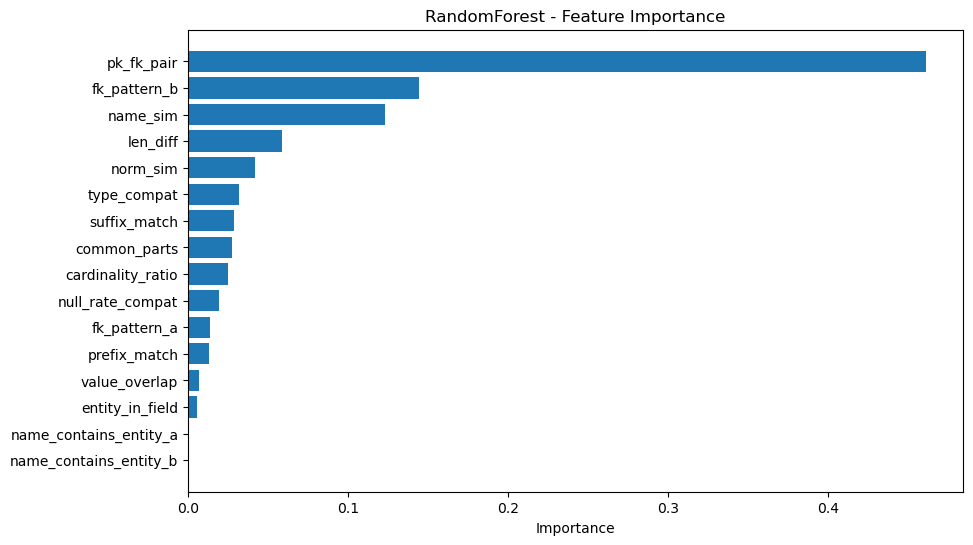

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# RandomForest
rf_importances = models['RandomForest'].feature_importances_
rf_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_importances
}).sort_values(by='importance', ascending=False)

# Affichage tableau
print("🌲 Feature importance - RandomForest")
print(rf_df)

# Graphique
plt.figure(figsize=(10,6))
plt.barh(rf_df['feature'], rf_df['importance'])
plt.gca().invert_yaxis()
plt.title("RandomForest - Feature Importance")
plt.xlabel("Importance")
plt.show()

⚡ Feature importance - XGBoost
                   feature  importance
6               pk_fk_pair    0.631017
5             fk_pattern_b    0.186299
3              type_compat    0.024185
4             fk_pattern_a    0.024014
12            suffix_match    0.021734
7             common_parts    0.020076
0                 name_sim    0.019657
1                 norm_sim    0.015589
2          entity_in_field    0.013405
15        null_rate_compat    0.010329
10                len_diff    0.010208
14       cardinality_ratio    0.009848
13           value_overlap    0.007221
11            prefix_match    0.006418
8   name_contains_entity_a    0.000000
9   name_contains_entity_b    0.000000


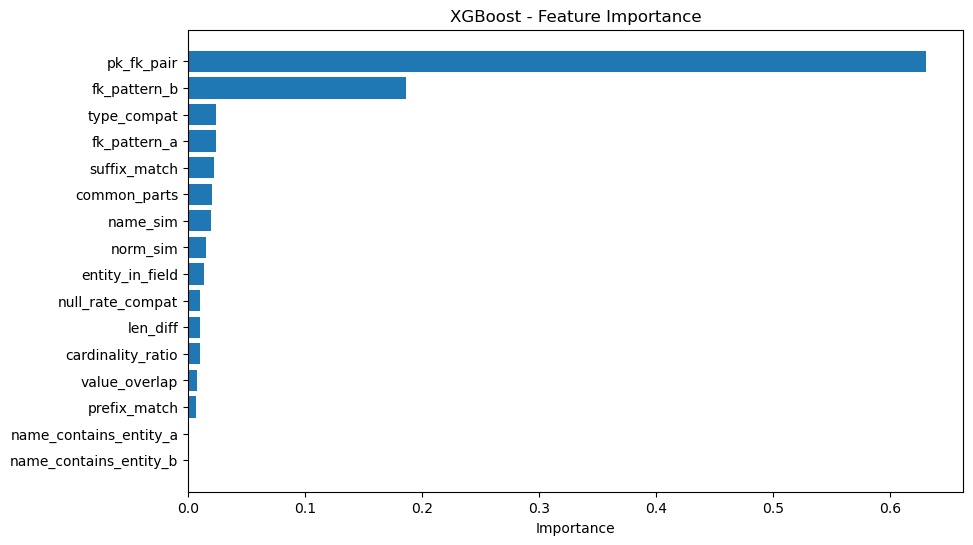

In [28]:
# XGBoost
xgb_importances = models['XGBoost'].feature_importances_
xgb_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_importances
}).sort_values(by='importance', ascending=False)

print("⚡ Feature importance - XGBoost")
print(xgb_df)

# Graphique
plt.figure(figsize=(10,6))
plt.barh(xgb_df['feature'], xgb_df['importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost - Feature Importance")
plt.xlabel("Importance")
plt.show()

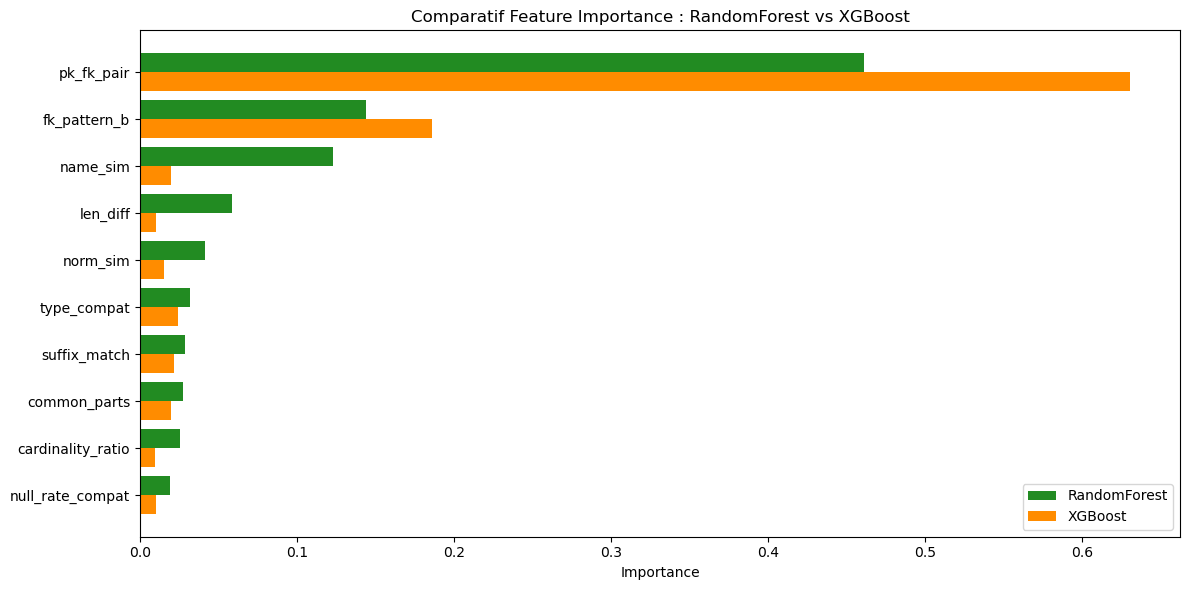

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Top 10 features pour RF et XGB
rf_top = rf_df.head(10).set_index('feature')
xgb_top = xgb_df.set_index('feature').reindex(rf_top.index)  # aligner mêmes features

# Largeur des barres
bar_width = 0.4
y_pos = np.arange(len(rf_top))

plt.figure(figsize=(12,6))

# Barres RF
plt.barh(y_pos - bar_width/2, rf_top['importance'], height=bar_width, label='RandomForest', color='forestgreen')
# Barres XGB
plt.barh(y_pos + bar_width/2, xgb_top['importance'], height=bar_width, label='XGBoost', color='darkorange')

plt.yticks(y_pos, rf_top.index)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Comparatif Feature Importance : RandomForest vs XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

## 10. 📊 Visualisations — Rapport complet par modèle

In [30]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

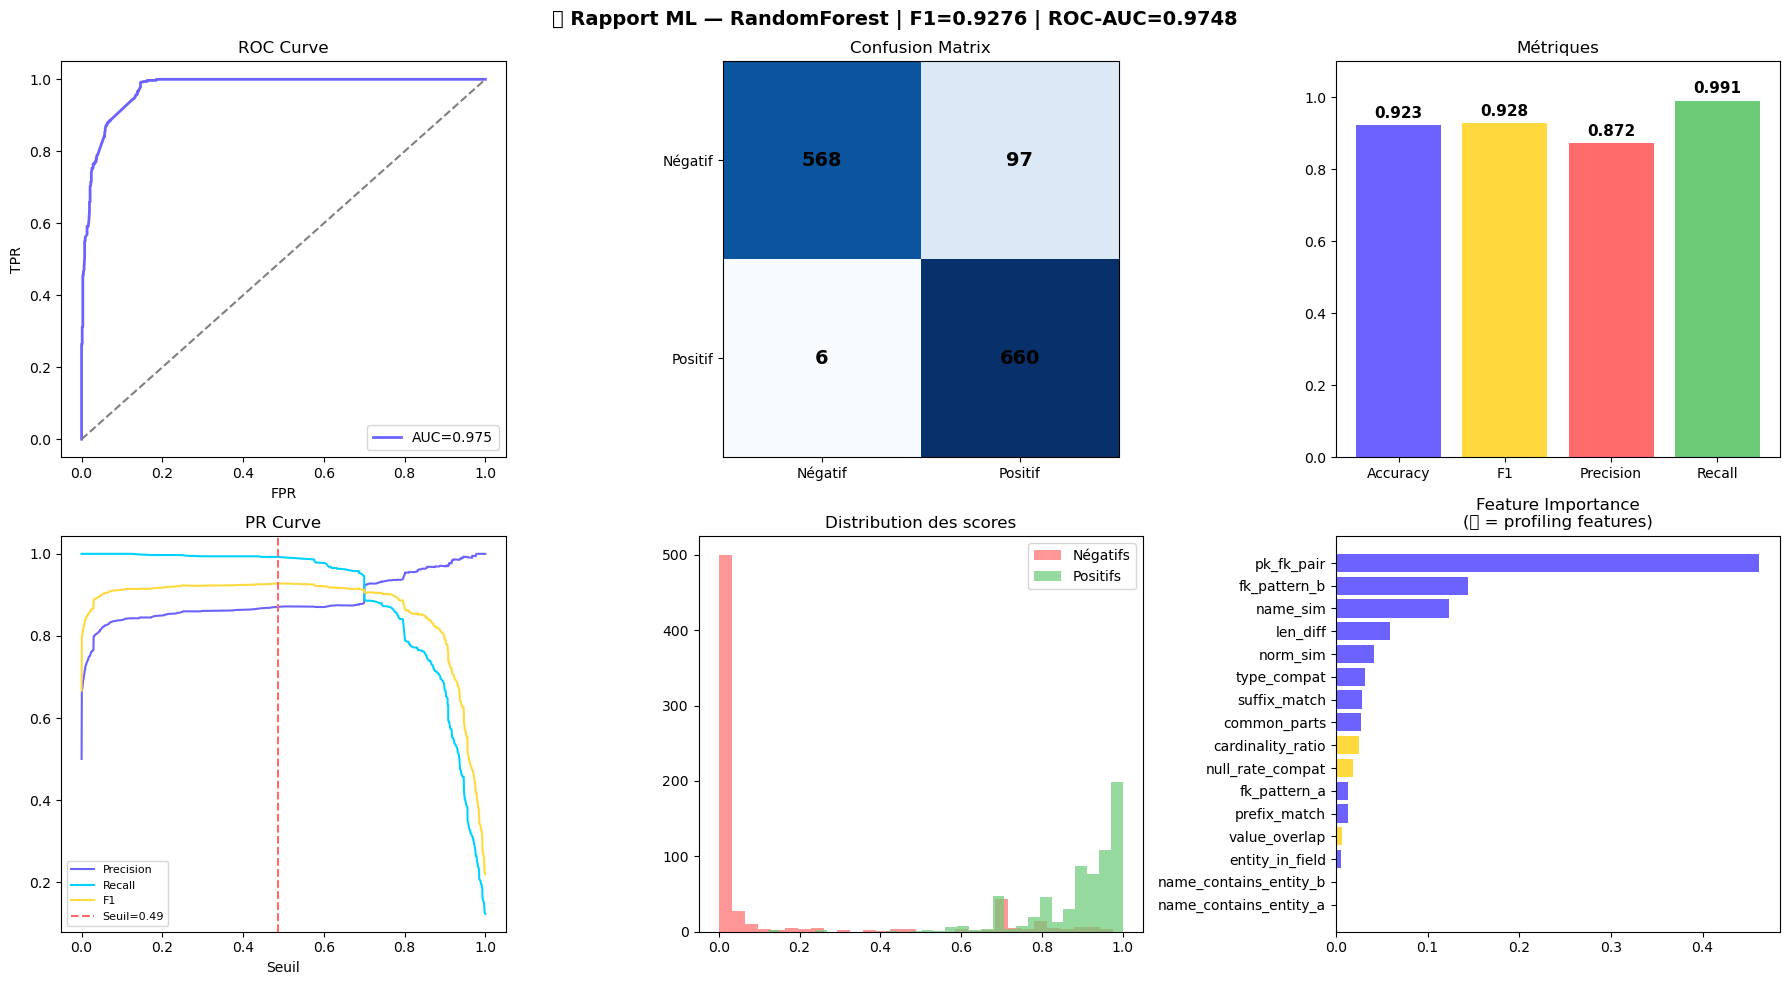

✅ Rapport RandomForest sauvegardé


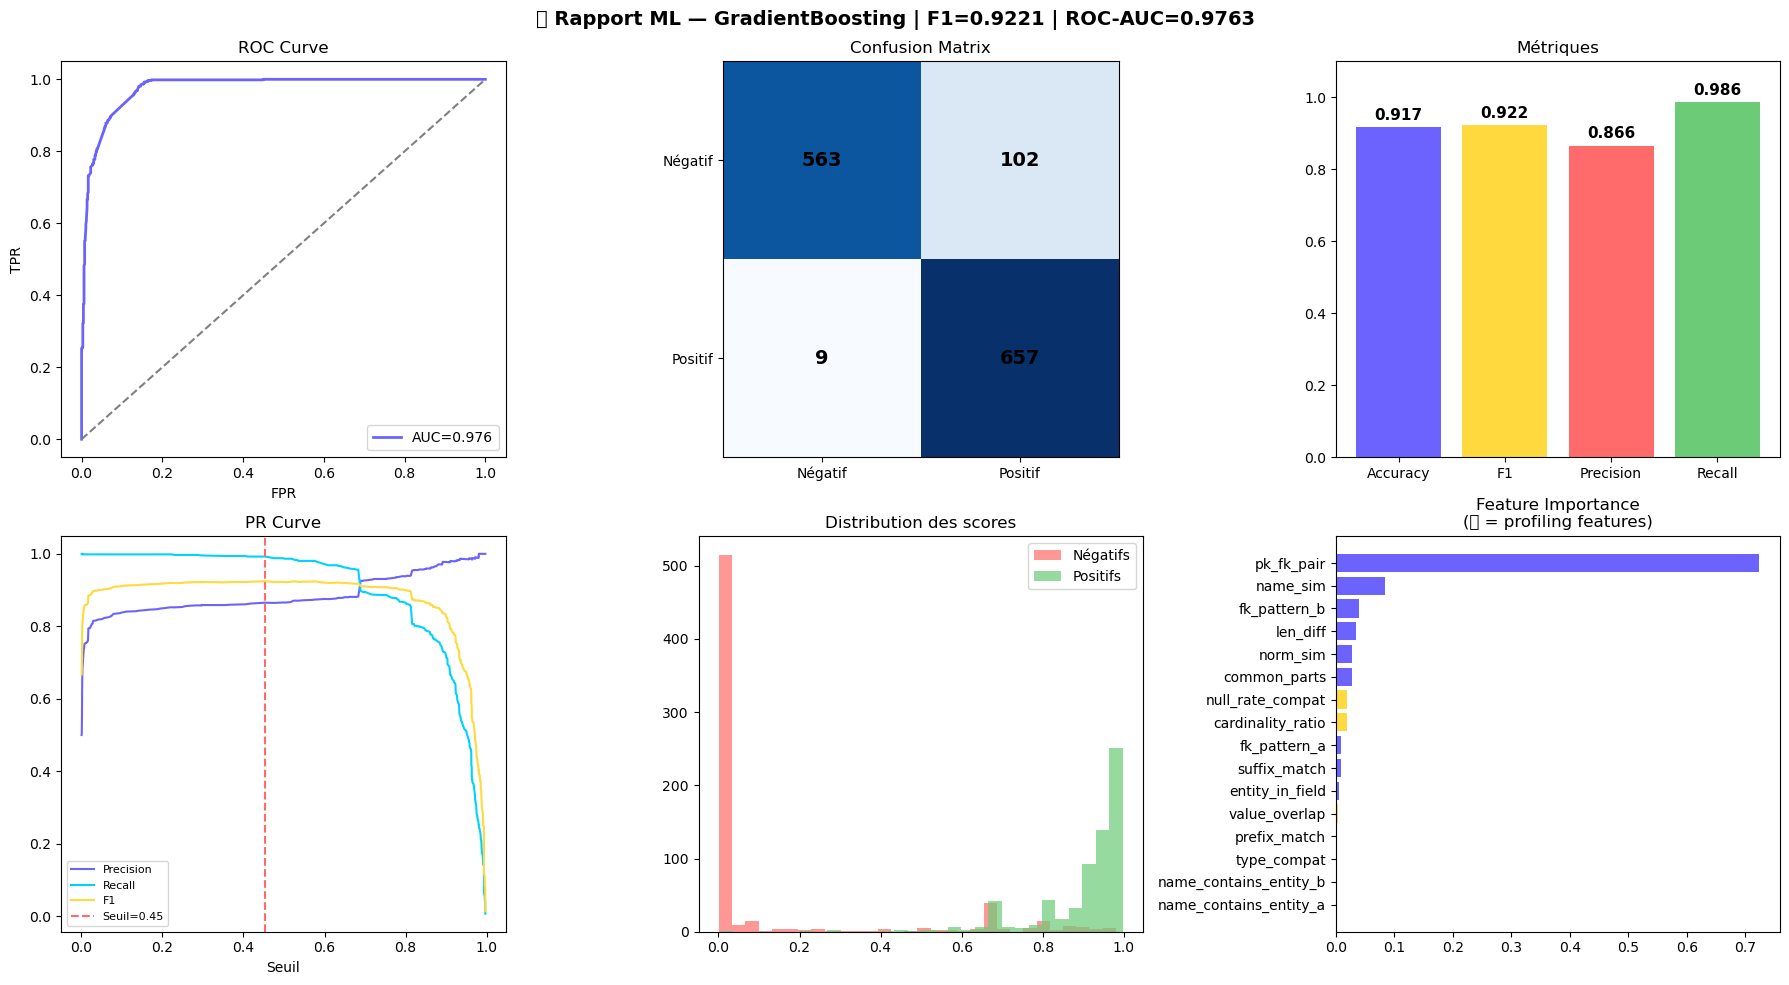

✅ Rapport GradientBoosting sauvegardé


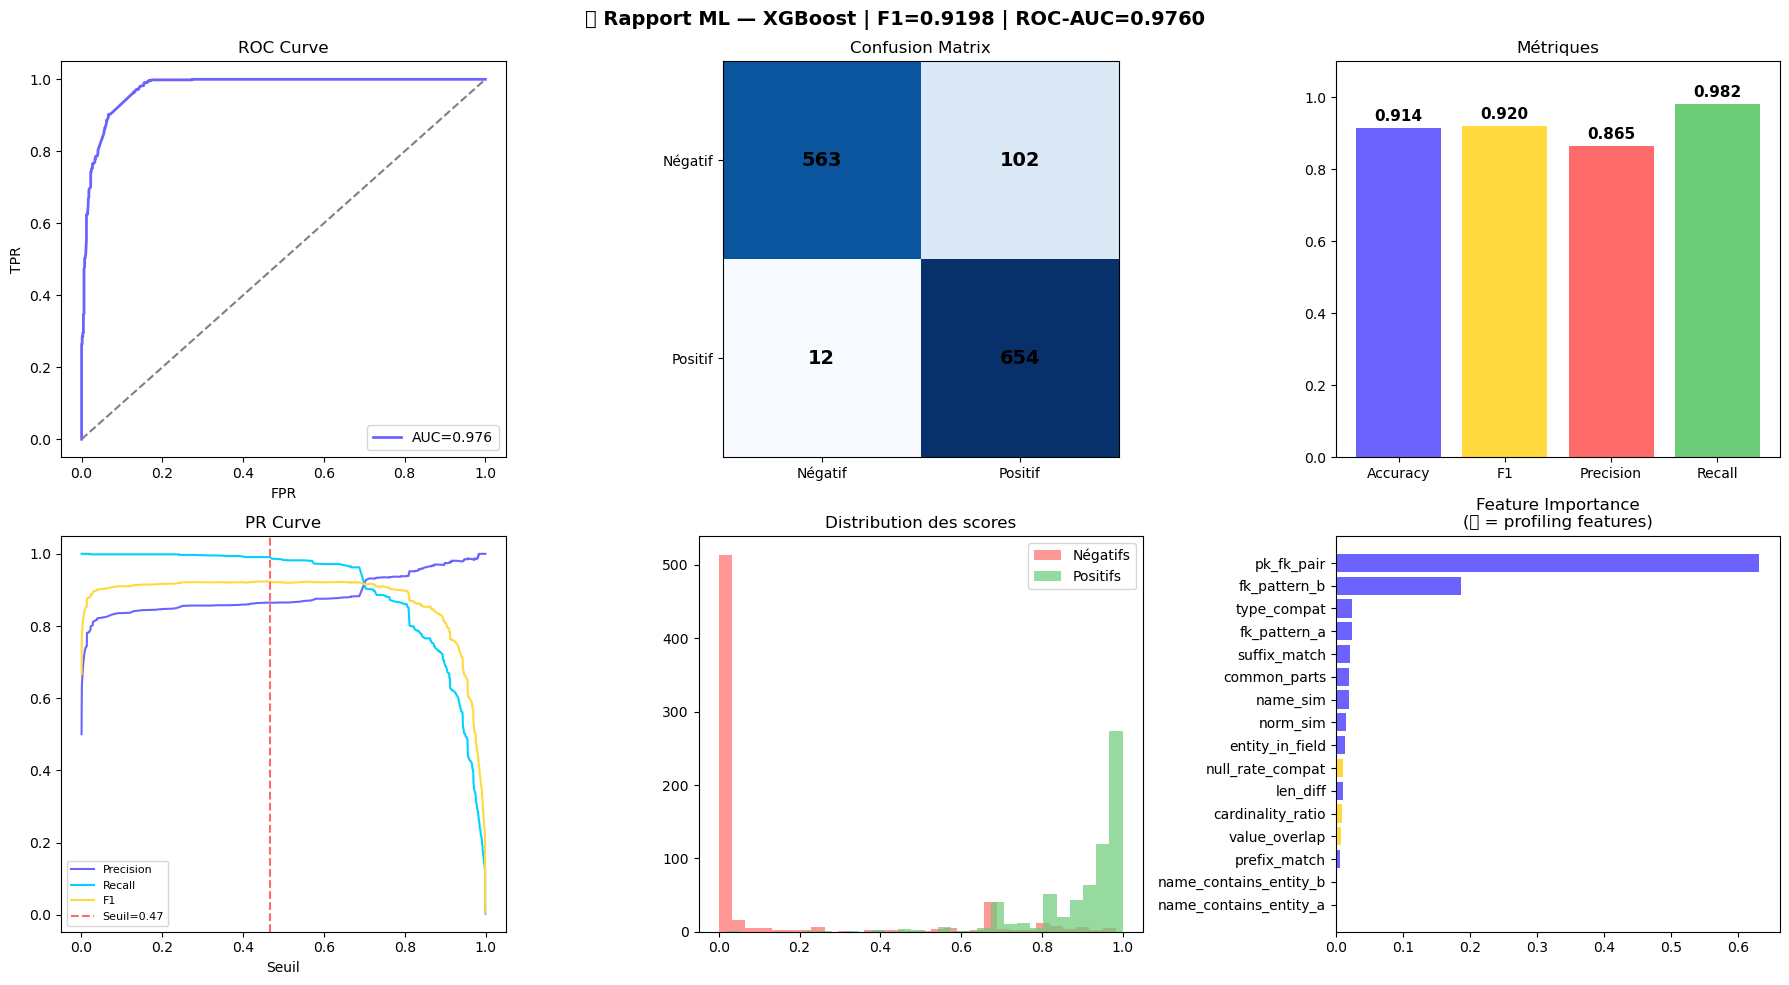

✅ Rapport XGBoost sauvegardé


In [31]:
for name, r in results.items():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'🤖 Rapport ML — {name} | F1={r["f1"]:.4f} | ROC-AUC={r["roc_auc"]:.4f}',
                 fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0,0].plot(fpr, tpr, color='#6c63ff', lw=2, label=f'AUC={r["roc_auc"]:.3f}')
    axes[0,0].plot([0,1],[0,1],'--',color='gray')
    axes[0,0].set_title('ROC Curve'); axes[0,0].legend()
    axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')

    # Confusion Matrix
    cm = r['cm']
    im = axes[0,1].imshow(cm, cmap='Blues')
    axes[0,1].set_title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            axes[0,1].text(j, i, cm[i,j], ha='center', va='center',
                           color='black', fontsize=14, fontweight='bold')
    axes[0,1].set_xticks([0,1]); axes[0,1].set_yticks([0,1])
    axes[0,1].set_xticklabels(['Négatif','Positif'])
    axes[0,1].set_yticklabels(['Négatif','Positif'])

    # Métriques
    metrics = {'Accuracy': r['acc'], 'F1': r['f1'], 'Precision': r['prec'], 'Recall': r['rec']}
    colors  = ['#6c63ff','#ffd93d','#ff6b6b','#6bcb77']
    bars    = axes[0,2].bar(metrics.keys(), metrics.values(), color=colors)
    axes[0,2].set_ylim(0, 1.1); axes[0,2].set_title('Métriques')
    for bar, v in zip(bars, metrics.values()):
        axes[0,2].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}',
                       ha='center', fontsize=11, fontweight='bold')

    # PR Curve
    prec_c, rec_c, thr_c = precision_recall_curve(y_test, r['y_proba'])
    f1_c = 2*prec_c[:-1]*rec_c[:-1]/(prec_c[:-1]+rec_c[:-1]+1e-9)
    axes[1,0].plot(thr_c, prec_c[:-1], color='#6c63ff', label='Precision')
    axes[1,0].plot(thr_c, rec_c[:-1],  color='#00d2ff', label='Recall')
    axes[1,0].plot(thr_c, f1_c,         color='#ffd93d', label='F1')
    best_thr = thr_c[np.argmax(f1_c)]
    axes[1,0].axvline(best_thr, color='#ff6b6b', linestyle='--', label=f'Seuil={best_thr:.2f}')
    axes[1,0].set_title('PR Curve'); axes[1,0].legend(fontsize=8)
    axes[1,0].set_xlabel('Seuil')

    # Distribution des scores
    pos_scores = r['y_proba'][y_test == 1]
    neg_scores = r['y_proba'][y_test == 0]
    axes[1,1].hist(neg_scores, bins=30, alpha=0.7, color='#ff6b6b', label='Négatifs')
    axes[1,1].hist(pos_scores, bins=30, alpha=0.7, color='#6bcb77', label='Positifs')
    axes[1,1].set_title('Distribution des scores'); axes[1,1].legend()

    # Feature Importance
    if hasattr(r['model'], 'feature_importances_'):
        importances = r['model'].feature_importances_
        idx = np.argsort(importances)
        colors_fi = ['#ffd93d' if FEATURE_COLS[i] in
                     ['value_overlap','cardinality_ratio','null_rate_compat']
                     else '#6c63ff' for i in idx]
        axes[1,2].barh([FEATURE_COLS[i] for i in idx], importances[idx], color=colors_fi)
        axes[1,2].set_title('Feature Importance\n(🟡 = profiling features)')

    plt.tight_layout()
    plt.savefig(f'ml_report_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Rapport {name} sauvegardé')

## 11. 🔍 Cross-Validation (5-fold)

In [32]:
print(f'🔄 Cross-Validation 5-fold sur {BEST_MODEL_NAME}...\n')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for metric, scoring in [('Accuracy','accuracy'), ('F1','f1')]:
    scores = cross_val_score(BEST_MODEL, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'  {metric:10s} : {scores.mean():.4f} ± {scores.std():.4f}  '
          f'(min={scores.min():.4f} max={scores.max():.4f})')


print(f'\n✅ Cross-validation terminée')

🔄 Cross-Validation 5-fold sur RandomForest...

  Accuracy   : 0.9125 ± 0.0074  (min=0.9045 max=0.9241)
  F1         : 0.9187 ± 0.0062  (min=0.9122 max=0.9285)

✅ Cross-validation terminée


## 12. 🎯 Prédiction sur Paires Inconnues
**Corrections :**
- ✅ Seuil automatique via courbe Precision/Recall (max F1)
- ✅ sim() = bigrams Jaccard (pas de timeout)

📊 Seuil optimal (max F1) : 0.487
   Precision : 0.871 | Recall : 0.992 | F1 : 0.928


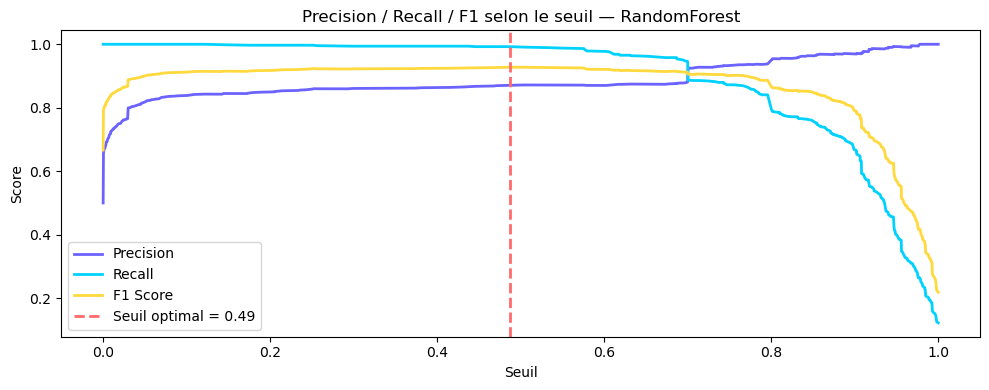


🔗 FK candidates: 4051 | 🔑 PK candidates: 2070
⏳ Génération des paires candidates (bigrams — rapide)...


In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(
    y_test, results[BEST_MODEL_NAME]['y_proba']
)
f1_scores_pr   = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1]+1e-9)
best_idx       = np.argmax(f1_scores_pr)
THRESHOLD_AUTO = float(thresholds_pr[best_idx])

print(f'📊 Seuil optimal (max F1) : {THRESHOLD_AUTO:.3f}')
print(f'   Precision : {precisions[best_idx]:.3f} | Recall : {recalls[best_idx]:.3f} | F1 : {f1_scores_pr[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds_pr, precisions[:-1], color='#6c63ff', label='Precision', lw=2)
ax.plot(thresholds_pr, recalls[:-1],    color='#00d2ff', label='Recall',    lw=2)
ax.plot(thresholds_pr, f1_scores_pr,    color='#ffd93d', label='F1 Score',  lw=2)
ax.axvline(THRESHOLD_AUTO, color='#ff6b6b', linestyle='--', lw=2,
           label=f'Seuil optimal = {THRESHOLD_AUTO:.2f}')
ax.set_xlabel('Seuil'); ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 selon le seuil — {BEST_MODEL_NAME}')
ax.legend(); plt.tight_layout(); plt.show()

THRESHOLD   = THRESHOLD_AUTO
MAX_RESULTS = 500

fk_cands = [r for _, r in df_fields.iterrows()
             if r['is_foreign_key'] or fk_pat(r['field_name']) > 0]
pk_cands = list(df_fields[df_fields['is_primary_key'] == True].iterrows())

print(f'\n🔗 FK candidates: {len(fk_cands)} | 🔑 PK candidates: {len(pk_cands)}')
print('⏳ Génération des paires candidates (bigrams — rapide)...')

unknown_pairs = []
for fa in fk_cands:
    for _, fb in pk_cands:
        if fa['entity_name'] == fb['entity_name']: continue
        if (fa['entity_name'], fb['entity_name']) in positive_set: continue
        feat = compute_features(
            fa['entity_name'], fa['field_name'], fa['data_type'], fa['is_primary_key'], fa['is_foreign_key'],
            fb['entity_name'], fb['field_name'], fb['data_type'], fb['is_primary_key'], fb['is_foreign_key']
        )
        feat.update({
            'source_entity': fa['entity_name'], 'source_field': fa['field_name'],
            'target_entity': fb['entity_name'], 'target_field': fb['field_name']
        })
        unknown_pairs.append(feat)

df_unknown = pd.DataFrame(unknown_pairs)
print(f'✅ {len(df_unknown):,} paires candidates générées')

X_unknown = df_unknown[FEATURE_COLS].values
proba     = BEST_MODEL.predict_proba(X_unknown)[:, 1]
df_unknown['confidence'] = proba

df_preds = (
    df_unknown[df_unknown['confidence'] >= THRESHOLD]
    .sort_values('confidence', ascending=False)
    .groupby(['source_entity','source_field'])
    .first()
    .reset_index()
    .sort_values('confidence', ascending=False)
    .head(MAX_RESULTS)
)

print(f'\n🎯 {len(df_preds)} relations prédites (seuil={THRESHOLD:.3f})')
print(f'   Confidence moyenne : {df_preds["confidence"].mean():.3f}')
print(f'   Confidence max     : {df_preds["confidence"].max():.3f}')
display(df_preds[['source_entity','source_field','target_entity','target_field','confidence']].head(25))

## 13. 📊 Visualisation des Prédictions

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Prédictions ML — {SOURCE_NAME}', fontsize=13)

axes[0].hist(df_preds['confidence'], bins=20, color='#6c63ff', edgecolor='white')
axes[0].axvline(THRESHOLD, color='#ff6b6b', linestyle='--', lw=2, label=f'Seuil={THRESHOLD:.2f}')
axes[0].set_title('Distribution des confidences'); axes[0].legend()
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Nombre de relations')

top10 = df_preds.head(10)
labels = [f'{r.source_entity}.{r.source_field}\n→ {r.target_entity}' for _, r in top10.iterrows()]
axes[1].barh(labels, top10['confidence'], color='#ffd93d')
axes[1].set_xlim(0, 1); axes[1].set_title('Top 10 prédictions')
axes[1].set_xlabel('Confidence')

plt.tight_layout()
plt.savefig('ml_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ml_predictions.png')

## 14. 💾 Sauvegarde en Base de Données
**Corrections :**
- ✅ source_field + target_field sauvegardés
- ✅ Dedup Python (pas de ON CONFLICT problématique)
- ✅ `confidence` (pas `confidence_score`)

In [ ]:
conn = await get_conn()

# ── FIX BUG 2 : supprimer d'abord, PUIS construire existing_set (vide) ──
deleted = await conn.execute("""
    DELETE FROM entity_relations
    WHERE source_id = $1
      AND detection_method = 'ml_predicted'
""", SOURCE_ID)
print(f'🗑️  Anciennes prédictions supprimées : {deleted}')

# existing_set = vide après le DELETE — plus de collision parasite
existing_set = set()
print(f'📊 Prédictions à insérer : {len(df_preds)}')

inserted = skipped = errors = 0
for _, row in df_preds.iterrows():
    key = (row['source_entity'], row['source_field'],
           row['target_entity'], row['target_field'])
    if key in existing_set:
        skipped += 1; continue
    try:
        await conn.execute("""
            INSERT INTO entity_relations
                (source_id, source_entity, source_field,
                 target_entity, target_field,
                 detection_method, confidence)
            VALUES ($1, $2, $3, $4, $5, 'ml_predicted', $6)
        """,
            SOURCE_ID,
            row['source_entity'], row['source_field'],
            row['target_entity'], row['target_field'],
            float(row['confidence'])
        )
        existing_set.add(key)
        inserted += 1
    except Exception as e:
        errors += 1
        print(f'  ⚠️ {row["source_entity"]}.{row["source_field"]} → '
              f'{row["target_entity"]}.{row["target_field"]}: {e}')

await conn.close()
print(f'\n✅ {inserted} insérées | ⏭️ {skipped} ignorées | ❌ {errors} erreurs')

## 15. 💿 Sauvegarde du Modèle (.pkl) + Résumé final

In [ ]:
model_path = f'best_model_{BEST_MODEL_NAME.lower()}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({
        'model':        BEST_MODEL,
        'feature_cols': FEATURE_COLS,
        'source_id':    SOURCE_ID,
        'threshold':    THRESHOLD,
    }, f)
print(f'✅ Modèle sauvegardé : {model_path}')

# ── Résumé final — FIX : confidence (pas confidence_score) ──
conn = await get_conn()
summary = await conn.fetch("""
    SELECT detection_method,
           COUNT(*) as total,
           ROUND(AVG(confidence)::numeric, 3) as avg_conf
    FROM entity_relations
    WHERE source_id = $1
    GROUP BY detection_method
    ORDER BY total DESC
""", SOURCE_ID)
await conn.close()

print('\n📋 Résumé complet des relations en DB :')
display(pd.DataFrame([dict(r) for r in summary]))

print(f'\n🎉 Pipeline ML v5 terminé !')
print(f'   Modèle    : {BEST_MODEL_NAME}')
print(f'   Features  : {len(FEATURE_COLS)} (13 noms/types + 3 profiling)')
print(f'   F1 Score  : {results[BEST_MODEL_NAME]["f1"]:.4f}')
print(f'   ROC-AUC   : {results[BEST_MODEL_NAME]["roc_auc"]:.4f}')
print(f'   Seuil     : {THRESHOLD:.3f} (auto via PR curve)')
print(f'   Insérées  : {inserted}')
print(f'   → Voir dans OnePilot UI : http://localhost:3000')